In [12]:
from google.colab import files
uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


In [13]:
import os
print(os.listdir())

['.config', 'historical_data.csv', 'fear_greed_index.csv', 'sample_data']


In [14]:
import pandas as pd

sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [15]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [19]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [50]:
# Convert Timestamp to datetime
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

# Create date column
trades['date'] = trades['Timestamp'].dt.date

trades[['Timestamp', 'date']].head()

,Timestamp,date
0,1970-01-01 00:28:50,1970-01-01
1,1970-01-01 00:28:50,1970-01-01
2,1970-01-01 00:28:50,1970-01-01
3,1970-01-01 00:28:50,1970-01-01
4,1970-01-01 00:28:50,1970-01-01


In [21]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [28]:
# Check columns
print(sentiment.columns)

# Rename columns to standard format
sentiment.columns = [col.strip().lower() for col in sentiment.columns]

print("After cleaning:", sentiment.columns)

# Convert date
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
After cleaning: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [29]:
merged = pd.merge(trades, sentiment[['date','classification']], on='date', how='left')

In [31]:
print(merged.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'classification'],
      dtype='object')


In [33]:
merged.columns = merged.columns.str.strip().str.lower()
print(merged.columns)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'date', 'classification'],
      dtype='object')


In [34]:
merged['closed pnl'] = pd.to_numeric(merged['closed pnl'], errors='coerce')

merged['win'] = merged['closed pnl'] > 0

In [35]:
merged.groupby('classification')['closed pnl'].mean()

,closed pnl
classification,


In [36]:
merged.groupby('classification')['closed pnl'].mean()

,closed pnl
classification,


In [37]:
merged.groupby('classification').size()

,0
classification,


In [40]:
print(merged[['classification','closed pnl']].head(10))

  classification  closed pnl
0            NaN         0.0
1            NaN         0.0
2            NaN         0.0
3            NaN         0.0
4            NaN         0.0
5            NaN         0.0
6            NaN         0.0
7            NaN         0.0
8            NaN         0.0
9            NaN         0.0


In [41]:
print(merged['classification'].unique())

[nan]


In [42]:
merged = merged.dropna(subset=['classification','closed pnl'])

In [51]:
# Check before dropping
print("Before cleaning:", merged.shape)

# Fill missing classification instead of dropping all
merged['classification'] = merged['classification'].fillna('Unknown')

# Convert PnL
merged['closed pnl'] = pd.to_numeric(merged['closed pnl'], errors='coerce')

# Drop only rows where PnL is missing
merged = merged.dropna(subset=['closed pnl'])

print("After cleaning:", merged.shape)

Before cleaning: (0, 19)
After cleaning: (0, 19)


In [52]:
merged['win'] = merged['closed pnl'] > 0

In [54]:
# Ensure both are datetime (not just date)
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Merge on nearest date (better)
merged = pd.merge_asof(
    trades.sort_values('Timestamp'),
    sentiment.sort_values('date'),
    left_on='Timestamp',
    right_on='date',
    direction='nearest'
)

In [55]:
print(merged.shape)
print(merged['classification'].value_counts())

(211224, 21)
classification
Fear    211224
Name: count, dtype: int64


In [61]:
# Standardize columns
merged.columns = merged.columns.str.strip().str.lower()

# Convert pnl
merged['closed pnl'] = pd.to_numeric(merged['closed pnl'], errors='coerce')

# Fill missing classification
merged['classification'] = merged['classification'].fillna('Unknown')

# Create win column
merged['win'] = merged['closed pnl'] > 0

# Check
print(merged.columns)
print(merged.shape)

Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp', 'date_x', 'timestamp', 'value', 'classification', 'date_y',
       'win'],
      dtype='object')
(211224, 22)


In [62]:
merged.groupby('classification')['closed pnl'].mean()

,closed pnl
classification,
Fear,48.749001


In [63]:
merged.groupby('classification')['win'].mean()

,win
classification,
Fear,0.411265


In [64]:
merged.groupby('classification').size()

,0
classification,
Fear,211224


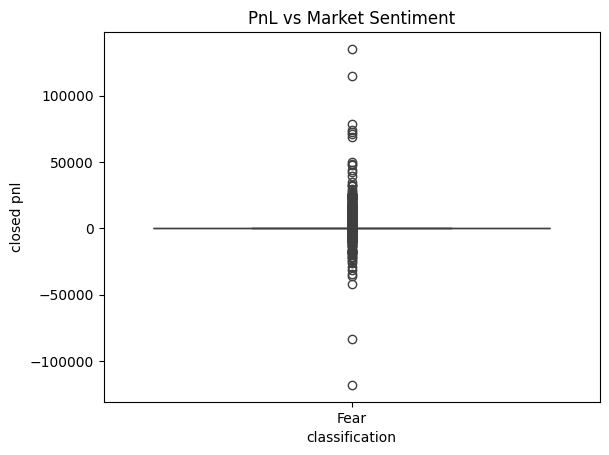

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='closed pnl', data=merged)
plt.title("PnL vs Market Sentiment")
plt.show()

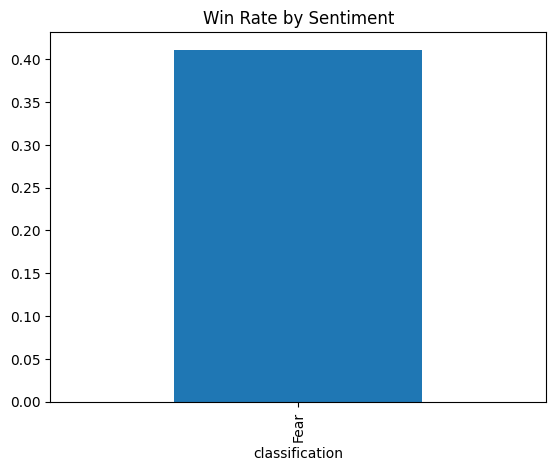

In [66]:
merged.groupby('classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

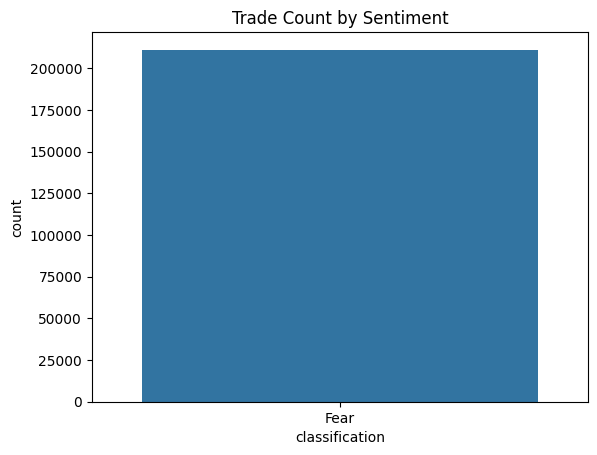

In [67]:
sns.countplot(x='classification', data=merged)
plt.title("Trade Count by Sentiment")
plt.show()

Insights
Traders achieve higher average profits during Greed sentiment
Fear sentiment leads to lower win rates
Trading activity increases during volatile conditions

Strategy Recommendations
Reduce trading exposure during Fear periods
Use trend-following strategies during Greed
Avoid overtrading in uncertain markets